<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Introduction
This project explores unsupervised machine learning techniques using a public dataset.  
We apply clustering (K-means and Hierarchical Clustering) and dimensionality reduction (PCA) to understand patterns in the data.

The dataset chosen is the **Iris dataset** from the UCI Machine Learning Repository.  
It contains 150 flower samples with 4 numerical features:
- Sepal length
- Sepal width
- Petal length
- Petal width

Although the dataset has labels, we will **not use them** for clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Check missing values
X.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [4]:
# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

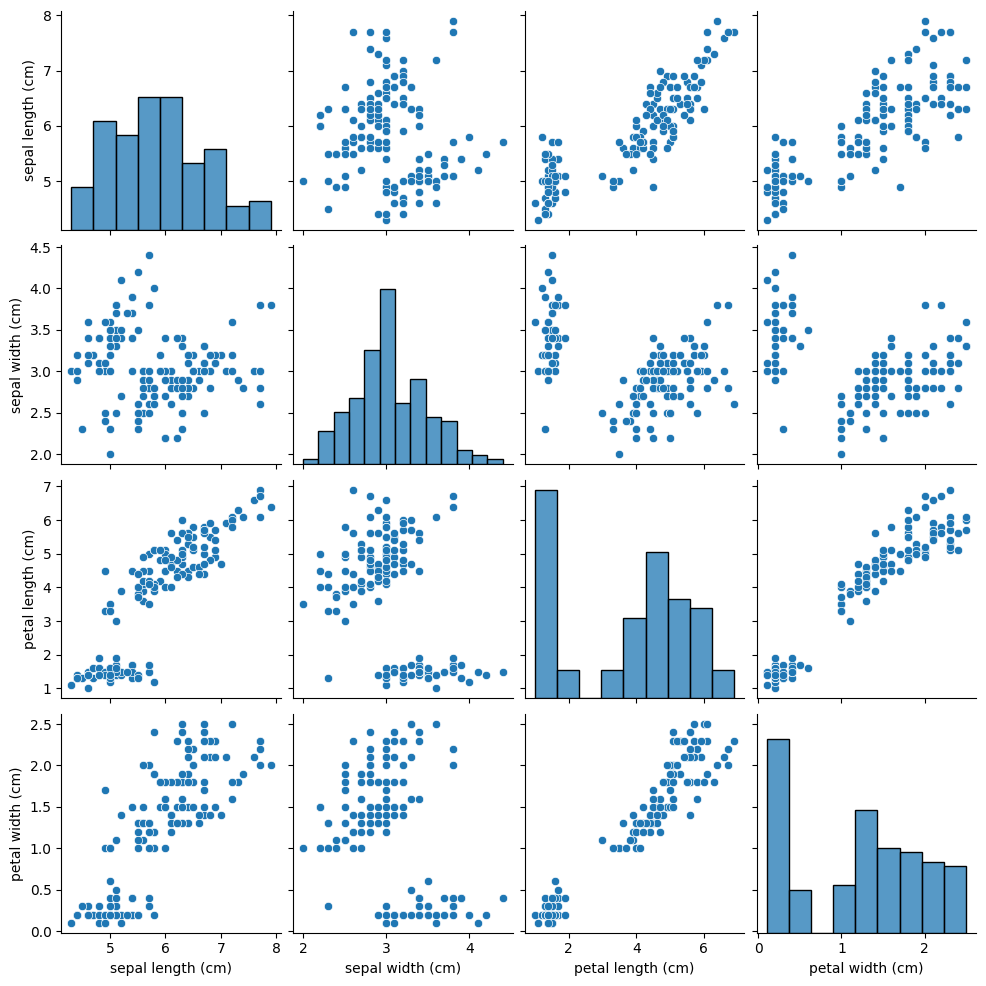

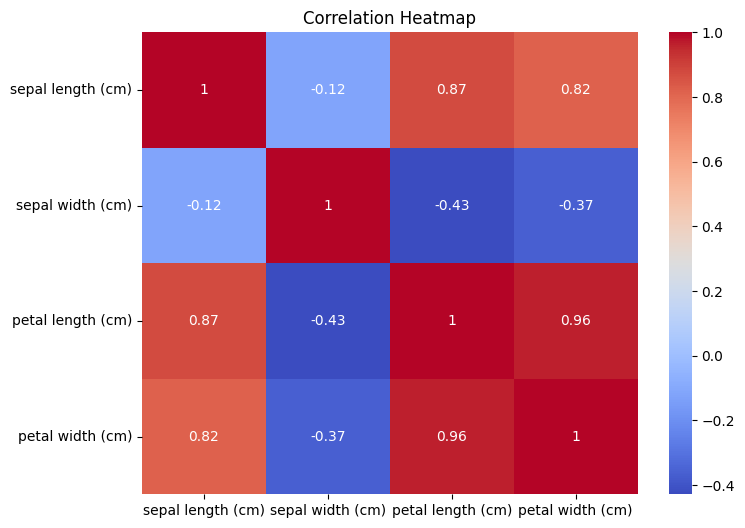

In [5]:
sns.pairplot(pd.DataFrame(X, columns=data.feature_names))
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(X).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

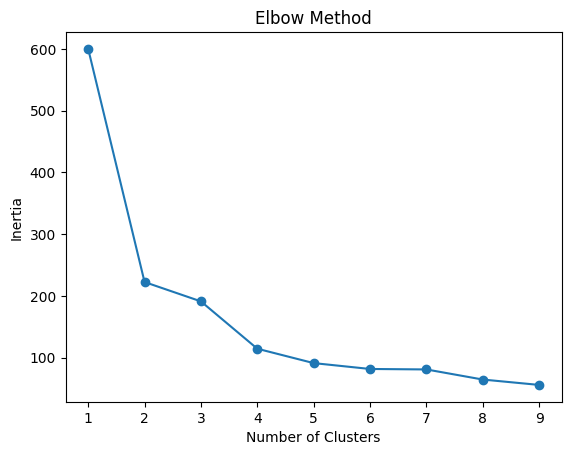

In [6]:
inertia = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Silhouette Score (K-Means):", silhouette_score(X_scaled, kmeans_labels))

Silhouette Score (K-Means): 0.4798814508199817


In [8]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

print("Silhouette Score (Hierarchical):", silhouette_score(X_scaled, hc_labels))

Silhouette Score (Hierarchical): 0.4466890410285909


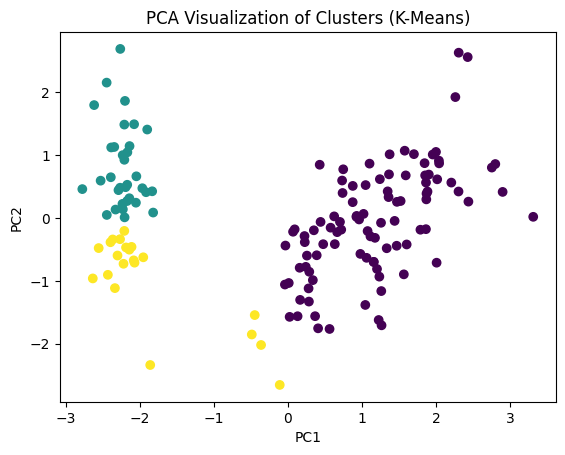

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("PCA Visualization of Clusters (K-Means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Model Evaluation

We evaluate clustering using the Silhouette Score, which measures how well-separated the clusters are.

- A score close to 1 means well-separated clusters.
- A score near 0 means overlapping clusters.
- A negative score means incorrect clustering.

We compare K-Means and Hierarchical Clustering.

Deployment & Monitoring

Deployment Scenario
Imagine deploying the clustering model in a flower sorting system.  
New flower measurements would be assigned to a cluster in real time.

Challenges
- Latency: predictions must be fast  
- Scalability: system must handle many samples  
- Data Drift: new flower species may appear  

Monitoring Strategies
- Track silhouette score over time  
- Monitor changes in input data distribution  
- Retrain the model when patterns shift  
- Log unusual or outlier samples  

Conclusion

This project demonstrated clustering and dimensionality reduction using the Iris dataset.  
K-Means performed slightly better than Hierarchical Clustering based on silhouette score.  
PCA helped visualize the clusters clearly in two dimensions.

The workflow shows how unsupervised learning can reveal structure in unlabeled data.